In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    precision_score, recall_score, f1_score
)

import seaborn as sns


In [3]:
# Paths
DATASET_ROOT = "uavdt"
TRAIN_DIR = os.path.join(DATASET_ROOT, "images/train")
VAL_DIR   = os.path.join(DATASET_ROOT, "images/val")

# Training
IMG_SIZE = 128
BATCH_SIZE = 32
LATENT_DIM = 128
EPOCHS = 50
LR = 1e-3
ANOMALY_RATIO = 0.10

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cuda


In [4]:
class UAVDTDataset(Dataset):
    def __init__(self, image_dir, anomaly_ratio=0.0):
        self.image_paths = [
            os.path.join(image_dir, f)
            for f in os.listdir(image_dir)
            if f.lower().endswith(".jpg")
        ]

        self.transform = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor()
        ])

        self.anomaly_count = int(len(self.image_paths) * anomaly_ratio)

    def __len__(self):
        return len(self.image_paths)

    def inject_anomaly(self, img):
        noise = torch.randn_like(img) * 0.4
        return torch.clamp(img + noise, 0, 1)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        img = self.transform(img)

        label = 0  # normal
        if idx < self.anomaly_count:
            img = self.inject_anomaly(img)
            label = 1  # anomaly

        return img, label


In [5]:
train_dataset = UAVDTDataset(TRAIN_DIR, anomaly_ratio=0.0)
val_dataset   = UAVDTDataset(VAL_DIR, anomaly_ratio=ANOMALY_RATIO)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [6]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU(),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(128 * 16 * 16, LATENT_DIM)
        self.fc_logvar = nn.Linear(128 * 16 * 16, LATENT_DIM)

        self.decoder_input = nn.Linear(LATENT_DIM, 128 * 16 * 16)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        z = self.decoder_input(z).view(-1, 128, 16, 16)
        return self.decoder(z), mu, logvar


In [7]:
def vae_loss(recon, x, mu, logvar):
    recon_loss = nn.functional.mse_loss(recon, x, reduction="mean")
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss


In [8]:
model = VAE().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)

train_losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    for imgs, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs = imgs.to(DEVICE)

        optimizer.zero_grad()
        recon, mu, logvar = model(imgs)
        loss = vae_loss(recon, imgs, mu, logvar)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}")


Epoch 1/50: 100%|██████████| 19/19 [00:08<00:00,  2.21it/s]


Epoch 1: Loss = 0.0460


Epoch 2/50: 100%|██████████| 19/19 [00:03<00:00,  5.48it/s]


Epoch 2: Loss = 0.0404


Epoch 3/50: 100%|██████████| 19/19 [00:03<00:00,  5.44it/s]


...

Epoch 48: Loss = 0.0360


Epoch 49/50: 100%|██████████| 19/19 [00:03<00:00,  4.95it/s]


Epoch 49: Loss = 0.0364


Epoch 50/50: 100%|██████████| 19/19 [00:03<00:00,  4.86it/s]

Epoch 50: Loss = 0.0359


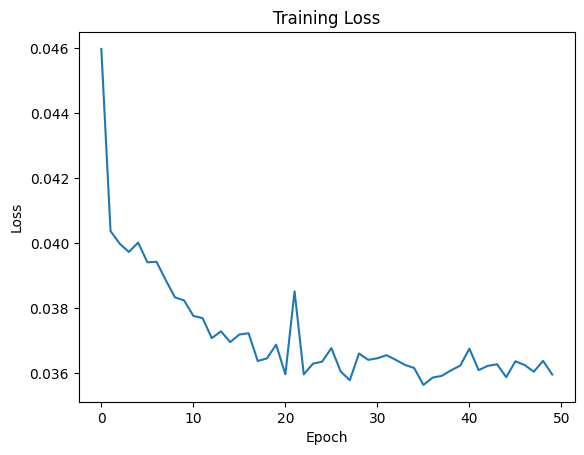

In [9]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


In [18]:
SAVE_DIR = "checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PATH = os.path.join(SAVE_DIR, "vae_uavdt.pth")

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epoch": EPOCHS,
    "latent_dim": LATENT_DIM,
    "img_size": IMG_SIZE
}, MODEL_PATH)

print(f"Model saved to {MODEL_PATH}")

Model saved to checkpoints\vae_uavdt.pth


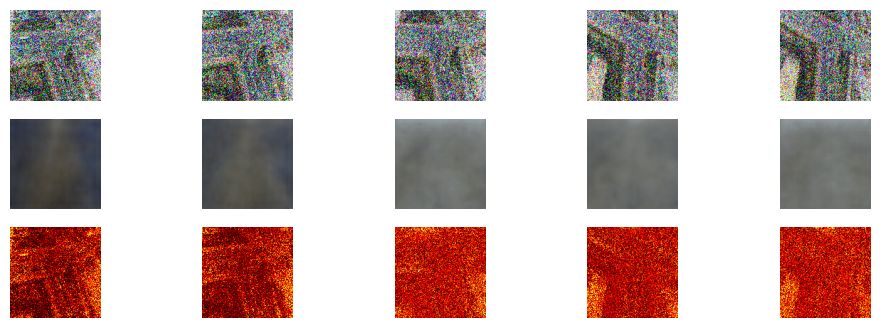

In [10]:
model.eval()
imgs, labels = next(iter(val_loader))
imgs = imgs.to(DEVICE)

with torch.no_grad():
    recon, _, _ = model(imgs)

error_map = torch.mean((imgs - recon) ** 2, dim=1)

plt.figure(figsize=(12,4))
for i in range(5):
    plt.subplot(3,5,i+1)
    plt.imshow(imgs[i].permute(1,2,0).cpu())
    plt.axis("off")

    plt.subplot(3,5,i+6)
    plt.imshow(recon[i].permute(1,2,0).cpu())
    plt.axis("off")

    plt.subplot(3,5,i+11)
    plt.imshow(error_map[i].cpu(), cmap="hot")
    plt.axis("off")
plt.show()

In [11]:
scores, gt = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        recon, _, _ = model(imgs)
        loss = torch.mean((imgs - recon) ** 2, dim=(1,2,3))
        scores.extend(loss.cpu().numpy())
        gt.extend(labels.numpy())


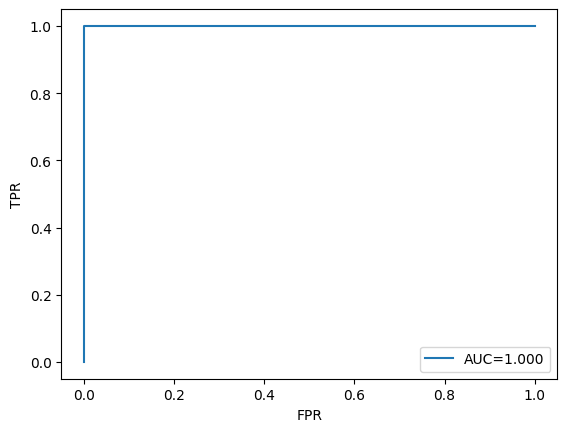

In [12]:
fpr, tpr, _ = roc_curve(gt, scores)
auc = roc_auc_score(gt, scores)

plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()


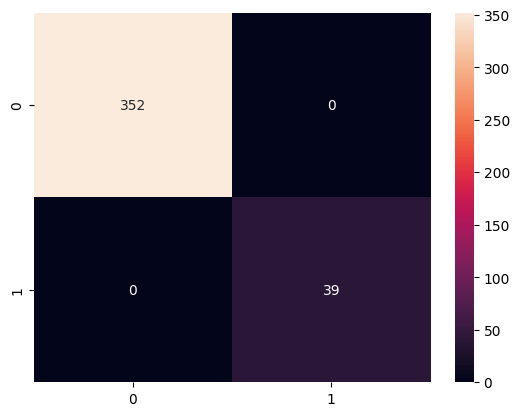

In [13]:
threshold = np.percentile(scores, 90)
preds = (np.array(scores) > threshold).astype(int)

cm = confusion_matrix(gt, preds)
sns.heatmap(cm, annot=True, fmt="d")
plt.show()


In [14]:
precision = precision_score(gt, preds)
recall    = recall_score(gt, preds)
f1        = f1_score(gt, preds)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC-AUC:", auc)


Precision: 1.0
Recall: 1.0
F1: 1.0
ROC-AUC: 1.0


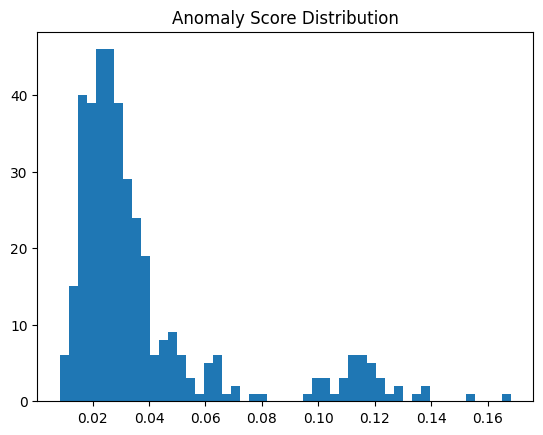

In [15]:
plt.hist(scores, bins=50)
plt.title("Anomaly Score Distribution")
plt.show()


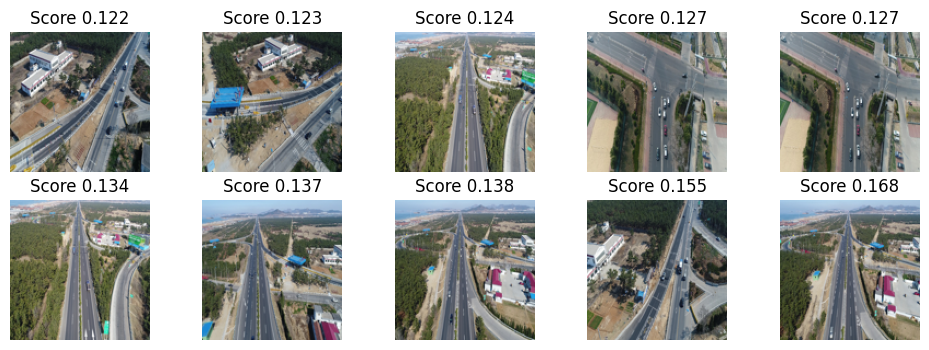

In [16]:
top_idx = np.argsort(scores)[-10:]

plt.figure(figsize=(12,4))
for i, idx in enumerate(top_idx):
    img_path = val_dataset.image_paths[idx]
    img = Image.open(img_path).resize((IMG_SIZE, IMG_SIZE))
    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(f"Score {scores[idx]:.3f}")
    plt.axis("off")
plt.show()


Total frames: 180
Estimating scores...


100%|██████████| 180/180 [00:00<00:00, 288.69it/s]


Threshold = 0.05688925795257092


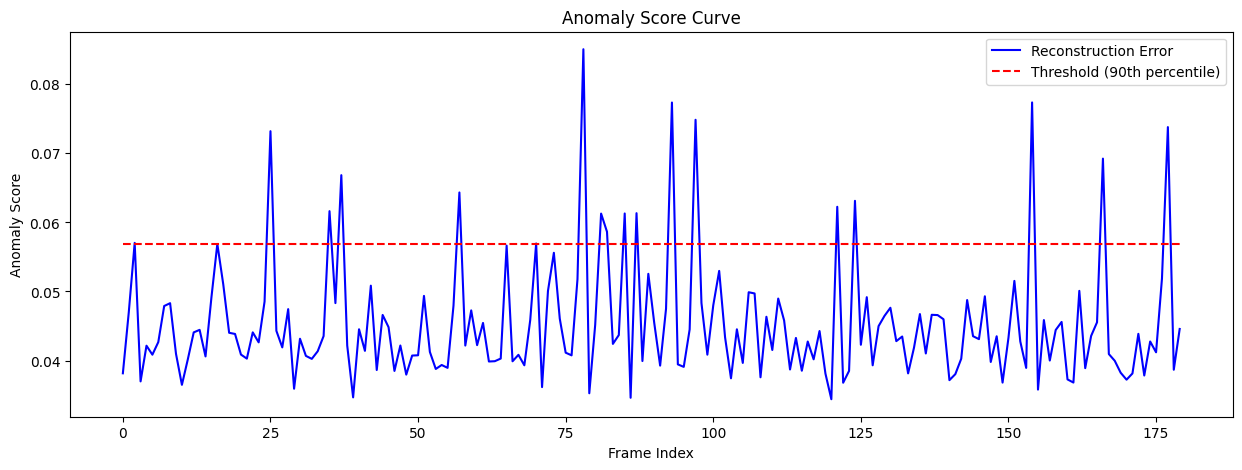

In [25]:
import os
import torch
import numpy as np
from torchvision import transforms
from PIL import Image
import torch.nn as nn
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt

# ---------------- PATHS ----------------
FRAME_DIR = "UCSD_Anomaly_Dataset/UCSDped2/Test/Test001"
MODEL_PATH = "checkpoints/vae_uavdt.pth"

IMG_SIZE = 128
LATENT_DIM = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PERCENTILE = 90

# ---------------- MODEL ----------------
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3,32,4,2,1), nn.ReLU(),
            nn.Conv2d(32,64,4,2,1), nn.ReLU(),
            nn.Conv2d(64,128,4,2,1), nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(128*16*16, LATENT_DIM)
        self.fc_logvar = nn.Linear(128*16*16, LATENT_DIM)
        self.decoder_input = nn.Linear(LATENT_DIM,128*16*16)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128,64,4,2,1), nn.ReLU(),
            nn.ConvTranspose2d(64,32,4,2,1), nn.ReLU(),
            nn.ConvTranspose2d(32,3,4,2,1), nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        return mu + torch.randn_like(std)*std

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        z = self.decoder_input(z).view(-1,128,16,16)
        return self.decoder(z), mu, logvar

# ---------------- LOAD MODEL ----------------
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model = VAE().to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

# ---------------- LOAD FRAMES ----------------
frames = sorted(glob(os.path.join(FRAME_DIR,"*.tif")))
print("Total frames:", len(frames))

# ---------------- THRESHOLD ----------------
scores = []
print("Estimating scores...")
with torch.no_grad():
    for f in tqdm(frames):
        img = Image.open(f).convert("RGB")
        img_t = transform(img).unsqueeze(0).to(DEVICE)
        recon, _, _ = model(img_t)
        score = torch.mean((img_t - recon)**2).item()
        scores.append(score)

scores = np.array(scores)
threshold = np.percentile(scores, PERCENTILE)
print("Threshold =", threshold)

# ---------------- PLOT ANOMALY CURVE ----------------
plt.figure(figsize=(15,5))
plt.plot(scores, label="Reconstruction Error", color="blue")
plt.hlines(threshold, 0, len(scores)-1, colors="red", linestyles="dashed", label=f"Threshold ({PERCENTILE}th percentile)")
plt.xlabel("Frame Index")
plt.ylabel("Anomaly Score")
plt.title("Anomaly Score Curve")
plt.legend()
plt.show()
